# Speech Emotion Recognition (SER)
**Objective:** Recognize human emotions from speech audio using deep learning.

## Step 1: Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Bidirectional, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import joblib
print('All libraries imported successfully')

All libraries imported successfully


## Step 2: Load RAVDESS Dataset

In [11]:
RAVDESS_PATH = os.path.join('data', 'RAVDESS')

EMOTIONS = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

file_paths = []
emotions = []

for root, dirs, files in os.walk(RAVDESS_PATH):
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            if len(parts) >= 3:
                emotion = EMOTIONS.get(parts[2], None)
                if emotion:
                    file_paths.append(os.path.join(root, file))
                    emotions.append(emotion)

df = pd.DataFrame({'path': file_paths, 'emotion': emotions})
print(f'Loaded {len(df)} audio files')
print(f'Emotions found: {sorted(df["emotion"].unique())}')
df.head()

Loaded 2880 audio files
Emotions found: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


,path,emotion
0,data\RAVDESS\Actor_01\03-01-01-01-01-01-01.wav,neutral
1,data\RAVDESS\Actor_01\03-01-01-01-01-02-01.wav,neutral
2,data\RAVDESS\Actor_01\03-01-01-01-02-01-01.wav,neutral
3,data\RAVDESS\Actor_01\03-01-01-01-02-02-01.wav,neutral
4,data\RAVDESS\Actor_01\03-01-02-01-01-01-01.wav,calm


## Step 3: Exploratory Data Analysis (EDA)

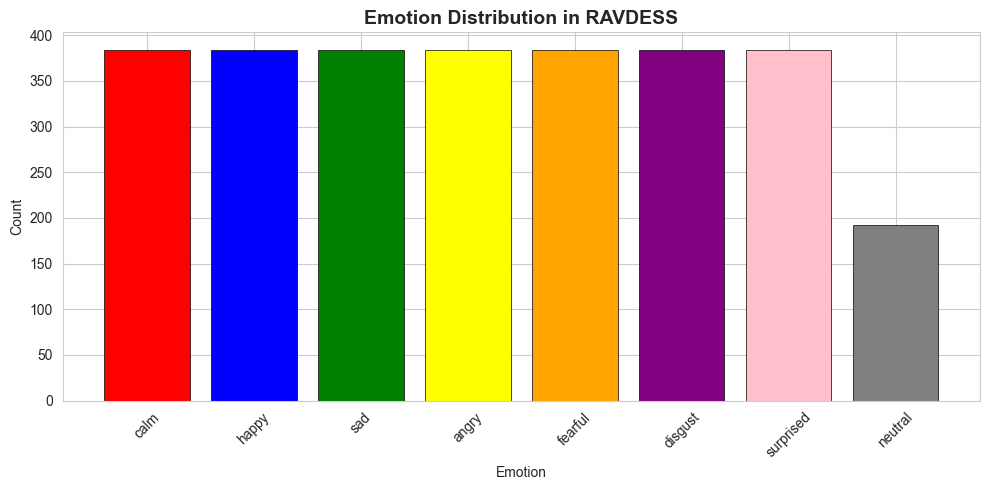

In [15]:
# 3.1 Emotion Distribution
plt.figure(figsize=(10, 5))
colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'pink', 'gray']
counts = df['emotion'].value_counts()
plt.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black', linewidth=0.5)
plt.title('Emotion Distribution in RAVDESS', fontsize=14, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

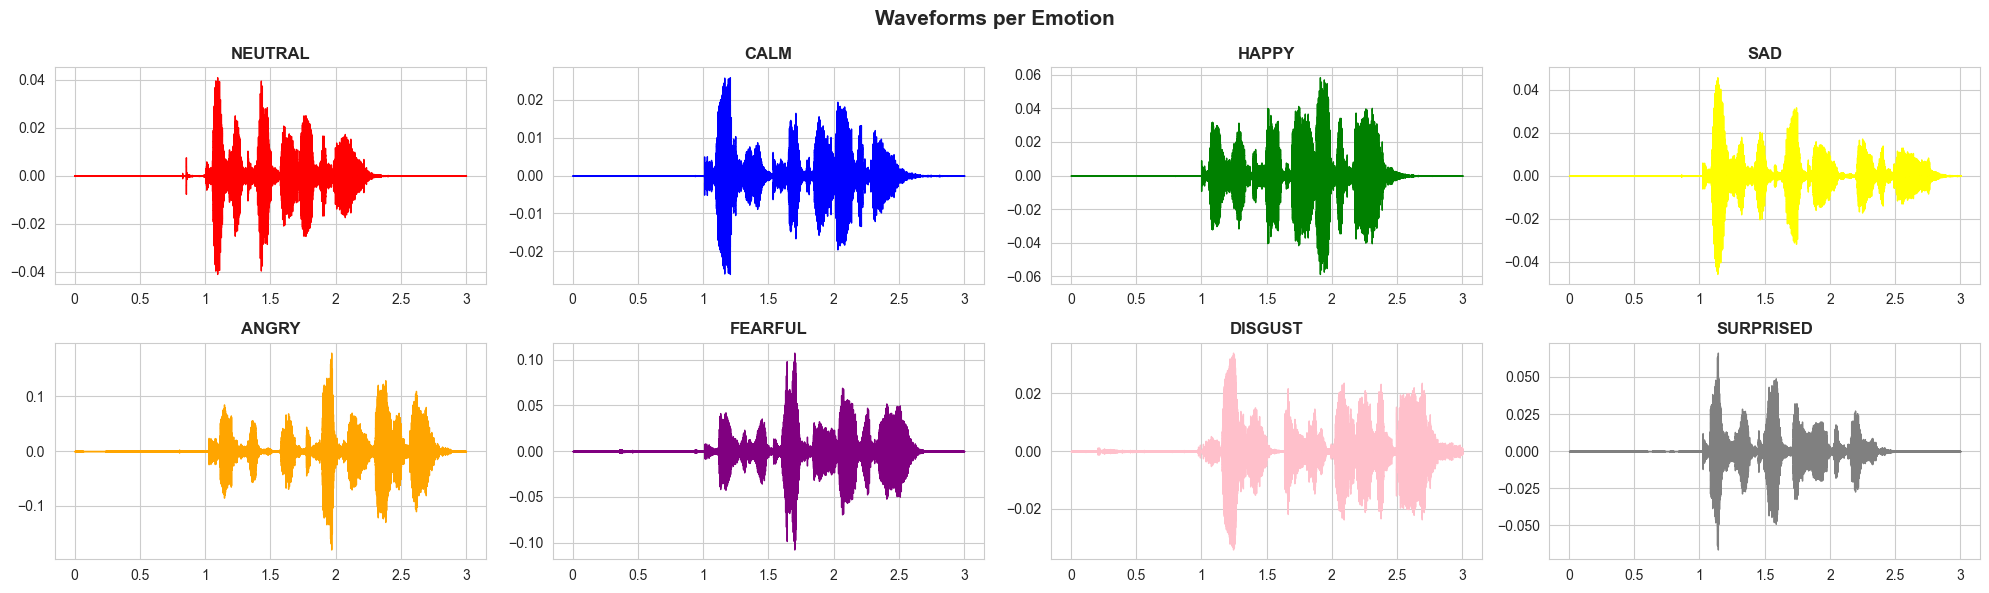

In [16]:
# 3.2 Waveform Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS.values()):
    sample = df[df['emotion'] == emotion].iloc[0]
    signal, sr = librosa.load(sample['path'], sr=22050, duration=3)
    librosa.display.waveshow(signal, sr=sr, ax=axes[i], color=colors[i])
    axes[i].set_title(emotion.upper(), fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Waveforms per Emotion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

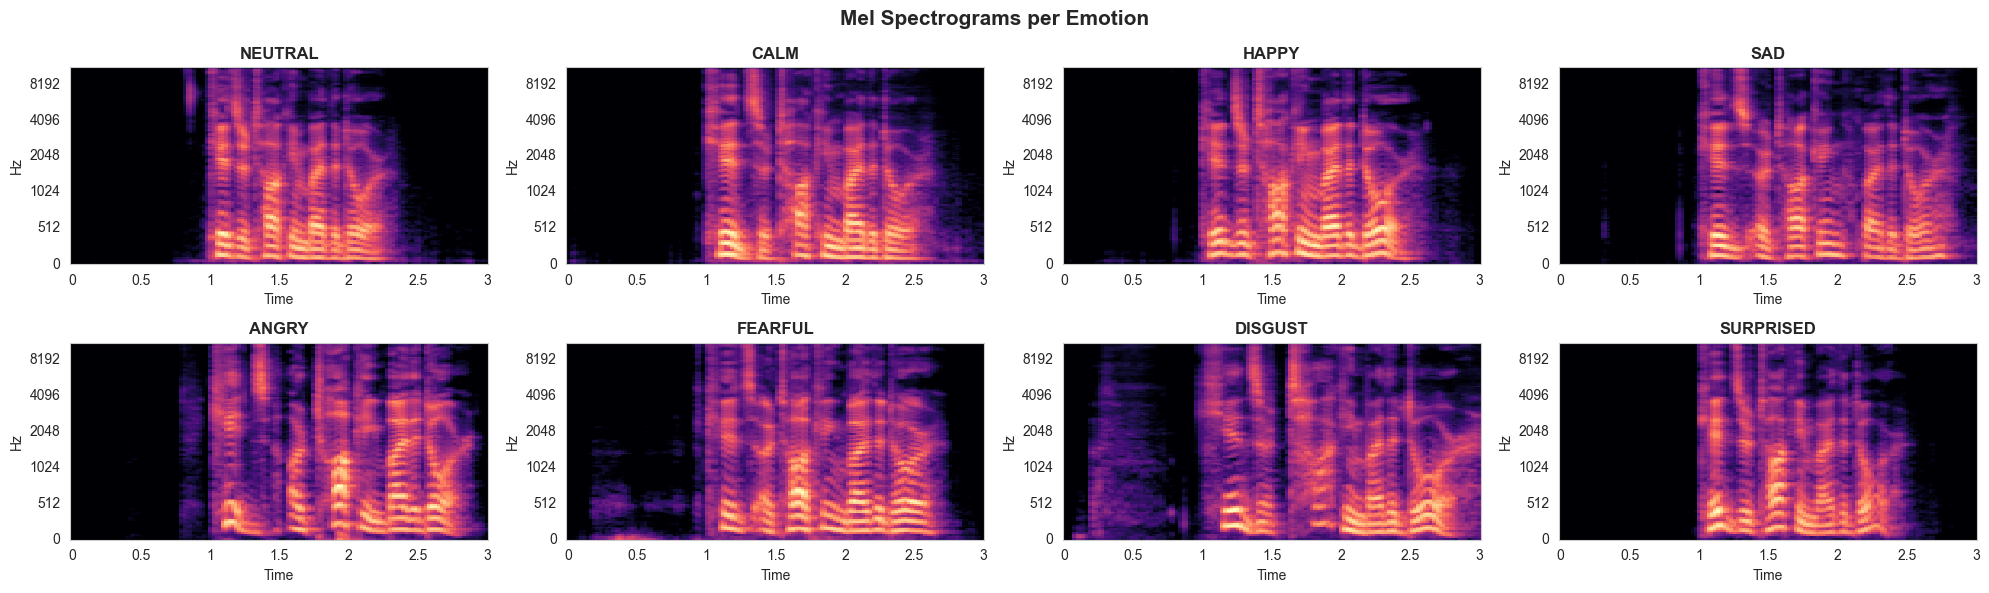

In [17]:
# 3.3 Mel Spectrogram Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS.values()):
    sample = df[df['emotion'] == emotion].iloc[0]
    signal, sr = librosa.load(sample['path'], sr=22050, duration=3)
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, ax=axes[i], x_axis='time', y_axis='mel', cmap='magma')
    axes[i].set_title(emotion.upper(), fontweight='bold')

plt.suptitle('Mel Spectrograms per Emotion', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Feature Extraction (MFCC)
We extract 40 MFCC coefficients from each audio file using librosa.

MFCCs represent the short-term power spectrum of sound and are ideal for speech analysis.

In [18]:
MAX_LEN = 130  # Fixed number of time frames

def extract_mfcc(file_path, sr=22050, duration=3, n_mfcc=40, max_len=MAX_LEN):
    """
    Extract MFCC features from an audio file.
    Returns a 2D array of shape (n_mfcc, max_len) = (40, 130)
    """
    signal, sr = librosa.load(file_path, sr=sr, duration=duration)

    # Pad short audio to ensure consistent length
    if len(signal) < sr * duration:
        signal = np.pad(signal, (0, sr * duration - len(signal)), mode='constant')

    # Compute MFCCs
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    # Fix width to max_len (pad or truncate)
    if mfccs.shape[1] < max_len:
        mfccs = np.pad(mfccs, ((0, 0), (0, max_len - mfccs.shape[1])))
    else:
        mfccs = mfccs[:, :max_len]

    return mfccs  # shape: (40, 130)


# Extract features for all files
X = []
y = []

print('Extracting MFCC features...')
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        feat = extract_mfcc(row['path'])
        X.append(feat)
        y.append(row['emotion'])
    except Exception as e:
        print(f'Error processing {row["path"]}: {e}')

X = np.array(X)
y = np.array(y)
print(f'\nFeatures extracted: X={X.shape}, y={y.shape}')

Extracting MFCC features...


100%|██████████| 2880/2880 [00:51<00:00, 56.15it/s]



Features extracted: X=(2880, 40, 130), y=(2880,)


## Step 5: Data Preprocessing

In [19]:
# 5.1 Encode emotion labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)

print(f'Classes: {label_encoder.classes_}')
print(f'One-hot shape: {y_onehot.shape}')

# 5.2 Normalize features
scaler = StandardScaler()
X_flat = X.reshape(X.shape[0], -1)
X_scaled = scaler.fit_transform(X_flat)
X_scaled = X_scaled.reshape(X.shape)

# 5.3 Transpose for model input: (samples, timesteps, features) = (samples, 130, 40)
X_ready = np.transpose(X_scaled, (0, 2, 1))
print(f'Model input shape: {X_ready.shape}')

# 5.4 Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_ready, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
One-hot shape: (2880, 8)
Model input shape: (2880, 130, 40)

Train: (2304, 130, 40)  |  Test: (576, 130, 40)


## Step 6: Build CNN-LSTM Model

In [20]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (130, 40)
num_classes = y_onehot.shape[1]                      # 8 emotions

model = Sequential([
    # CNN Feature Extractor
    Conv1D(64, kernel_size=5, activation='relu', padding='same', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # LSTM Temporal Modeling
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),

    # Classification Head
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 130, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,208 (606.28 KB)

 Trainable params: 154,568 (603.78 KB)

 Non-trainable params: 640 (2.50 KB)

## Step 7: Train the Model

In [21]:
os.makedirs('models', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('models/cnn_lstm_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('Training complete')

Epoch 1/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2006 - loss: 2.6878
Epoch 1: val_accuracy improved from None to 0.37326, saving model to models/cnn_lstm_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2548 - loss: 2.4170 - val_accuracy: 0.3733 - val_loss: 1.8003 - learning_rate: 0.0010
Epoch 2/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3066 - loss: 2.0622
Epoch 2: val_accuracy improved from 0.37326 to 0.41493, saving model to models/cnn_lstm_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3325 - loss: 1.9756 - val_accuracy: 0.4149 - val_loss: 1.6197 - learning_rate: 0.0010
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3586 - loss: 1.8458
Epoch 3: val_accuracy improved from 0.41493 to 0.48090, saving model to models/cnn_lstm_best.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3624 - loss: 1.8165 - val_accuracy: 0.4809 - val_loss: 1.4256 - learning_rate: 0.0010
Epoch 4/100
71/72 ━━━━━━━━━━

## Step 8: Evaluate the Model

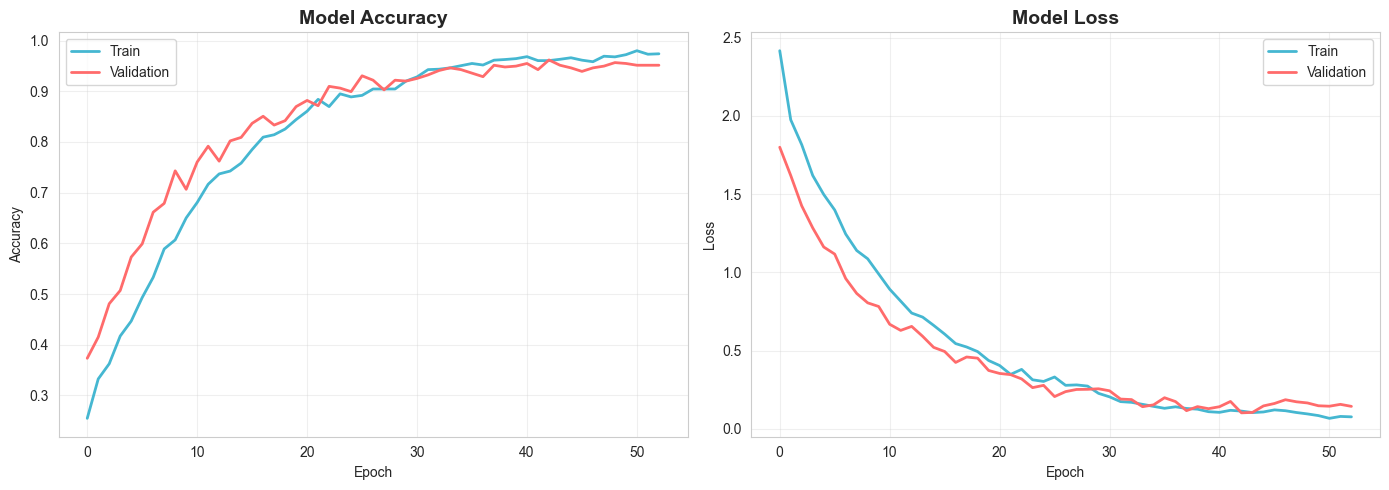

In [22]:
# 8.1 Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2, color='#45B7D1')
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#FF6B6B')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2, color='#45B7D1')
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#FF6B6B')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


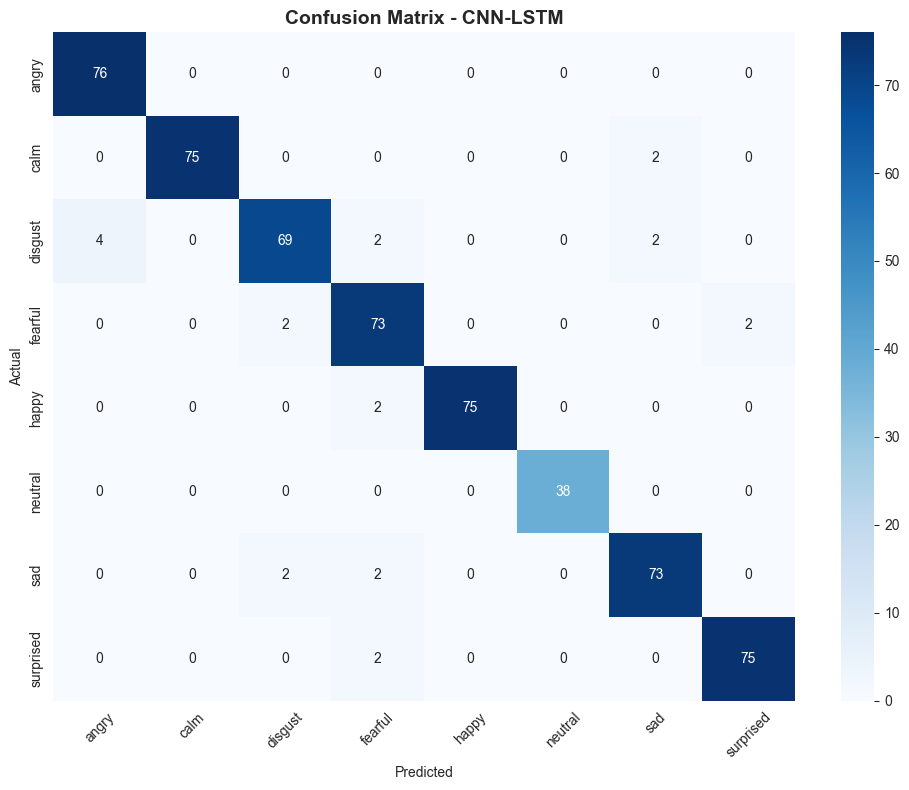

In [23]:
# 8.2 Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - CNN-LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# 8.3 Classification Report
print('=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

acc = accuracy_score(y_true_classes, y_pred_classes)
print(f'Overall Accuracy: {acc*100:.2f}%')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.95      1.00      0.97        76
        calm       1.00      0.97      0.99        77
     disgust       0.95      0.90      0.92        77
     fearful       0.90      0.95      0.92        77
       happy       1.00      0.97      0.99        77
     neutral       1.00      1.00      1.00        38
         sad       0.95      0.95      0.95        77
   surprised       0.97      0.97      0.97        77

    accuracy                           0.96       576
   macro avg       0.96      0.96      0.96       576
weighted avg       0.96      0.96      0.96       576

Overall Accuracy: 96.18%


## Step 9: Save Model and Artifacts

In [27]:
model.save('models/cnn_lstm_best.keras')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print('Saved:')
print('  models/cnn_lstm_best.keras  (trained model)')
print('  models/scaler.pkl           (feature scaler)')
print('  models/label_encoder.pkl    (label encoder)')
print('\nTo launch the web app run: streamlit run app.py')

Saved:
  models/cnn_lstm_best.keras  (trained model)
  models/scaler.pkl           (feature scaler)
  models/label_encoder.pkl    (label encoder)

To launch the web app run: streamlit run app.py
